# 🚀 Lab 49: Business Forecasting with Prophet

## 🎯 Objectives
By the end of this lab, you will be able to:
* Understand the fundamentals of time series forecasting using Prophet.
* Format datasets properly with Prophet’s required `ds` and `y` columns.
* Build and train Prophet forecasting models on business data.
* Generate and visualize forecasts with confidence intervals.
* Enhance model accuracy by incorporating holidays and external regressors.
* Interpret Prophet model components including trend, seasonality, and holiday effects.

## 🧰 Prerequisites
* Basic understanding of Python and pandas.
* Familiarity with matplotlib for plotting.
* General understanding of time series concepts (trend, seasonality).

## ⚙️ Environment Setup
### 🧒 ELI10
Before we start forecasting, we need to install the 'brain' (Prophet) and some helper tools for math and charts.

In [1]:
# Install the prophet library and other dependencies
!pip install -q prophet pandas numpy matplotlib scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from prophet.utilities import regressor_coefficients
from datetime import datetime
from sklearn.metrics import mean_absolute_error
import warnings

# Ignore warnings for a cleaner notebook output
warnings.filterwarnings("ignore")

# Set plotting defaults
plt.style.use("default")
plt.rcParams["figure.figsize"] = (12, 8)

print("Environment ready!")

Environment ready!


## 📥 Creating and Formatting the Dataset
### 🧒 ELI10
Prophet is picky! It only likes data with two specific column names: `ds` for the date and `y` for the number we are trying to predict.

### What we are doing
We are creating a synthetic retail sales dataset from scratch. This ensures we have a predictable 'ground truth' to test our model against.

### Why we are doing it
In the real world, sales aren't random; they grow over time (trend) and repeat patterns every week or year (seasonality). We simulate these to see if Prophet can find them.

In [3]:
# Set seed for reproducibility
np.random.seed(42)

# Define date range
start_date = datetime(2022, 1, 1)
end_date = datetime(2023, 12, 31)
dates = pd.date_range(start=start_date, end=end_date, freq="D")

# Generate synthetic sales components
base_sales = 1000
trend = np.linspace(0, 500, len(dates)) # Growth
seasonal = 200 * np.sin(2 * np.pi * np.arange(len(dates)) / 365.25) # Yearly
weekly = 100 * np.sin(2 * np.pi * np.arange(len(dates)) / 7) # Weekly
noise = np.random.normal(0, 50, len(dates)) # Randomness

sales = base_sales + trend + seasonal + weekly + noise

# Create initial DataFrame
df = pd.DataFrame({"date": dates, "sales": sales})

# Format for Prophet
prophet_df = df.copy().rename(columns={"date": "ds", "sales": "y"})
prophet_df["ds"] = pd.to_datetime(prophet_df["ds"])

print("Original Data (First 10):")
display(df.head(10))
print("\nProphet Formatted Data (First 5):")
display(prophet_df.head())
print(f"\nShape: {prophet_df.shape}")
print("\nMissing Values:")
print(prophet_df.isnull().sum())

Original Data (First 10):


,date,sales
0,2022-01-01,1024.835708
1,2022-01-02,1075.396119
2,2022-01-03,1138.128572
3,2022-01-04,1131.914353
4,2022-01-05,961.398523
5,2022-01-06,911.410937
6,2022-01-07,1025.498995
7,2022-01-08,1067.198067
8,2022-01-09,1087.633478
9,2022-01-10,1161.634442



Prophet Formatted Data (First 5):


,ds,y
0,2022-01-01,1024.835708
1,2022-01-02,1075.396119
2,2022-01-03,1138.128572
3,2022-01-04,1131.914353
4,2022-01-05,961.398523



Shape: (730, 2)

Missing Values:
ds    0
y     0
dtype: int64


## 🔍 Visualizing the Original Time Series
### 🧒 ELI10
Before asking a computer to guess the future, we should look at the past with our own eyes to see the patterns.

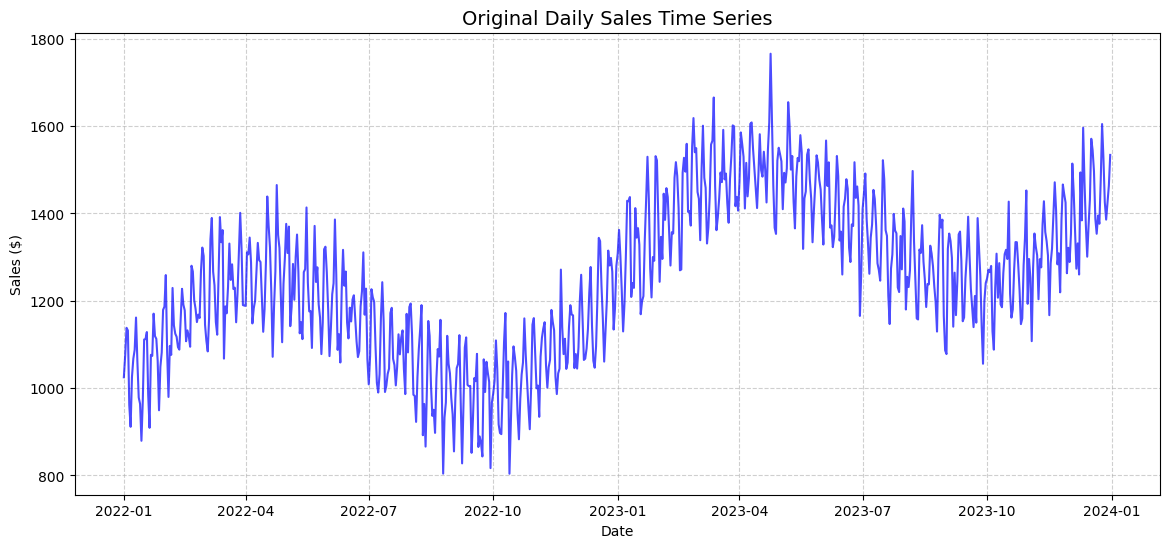

In [4]:
plt.figure(figsize=(14, 6))
plt.plot(prophet_df['ds'], prophet_df['y'], color='blue', alpha=0.7)
plt.title("Original Daily Sales Time Series", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Sales ($)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 📈 Basic Prophet Forecasting
### 🧒 ELI10
We are teaching the model the basic 'rhythm' of our business based on the past two years.

In [5]:
# Initialize basic model
model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True,
    seasonality_mode="additive"
)

# Fit the model
model.fit(prophet_df)

# Create 90-day future horizon
future = model.make_future_dataframe(periods=90)

# Predict
forecast = model.predict(future)

print(f"Future dataframe size: {len(future)}")
print("Last 5 future dates:")
display(future.tail())
print("\nForecast key columns (Last 5):")
display(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

Future dataframe size: 820
Last 5 future dates:


,ds
815,2024-03-26
816,2024-03-27
817,2024-03-28
818,2024-03-29
819,2024-03-30



Forecast key columns (Last 5):


,ds,yhat,yhat_lower,yhat_upper
815,2024-03-26,1778.674262,1719.557076,1839.888798
816,2024-03-27,1686.719203,1627.659231,1752.098318
817,2024-03-28,1644.563549,1576.569967,1705.304652
818,2024-03-29,1657.728137,1594.169741,1721.712705
819,2024-03-30,1740.398520,1676.413201,1801.777567


## 📊 Visualizing the Forecast
### 🧒 ELI10
Black dots are real sales, the blue line is what the computer thinks happened, and the light blue area is the 'maybe' zone for the future.

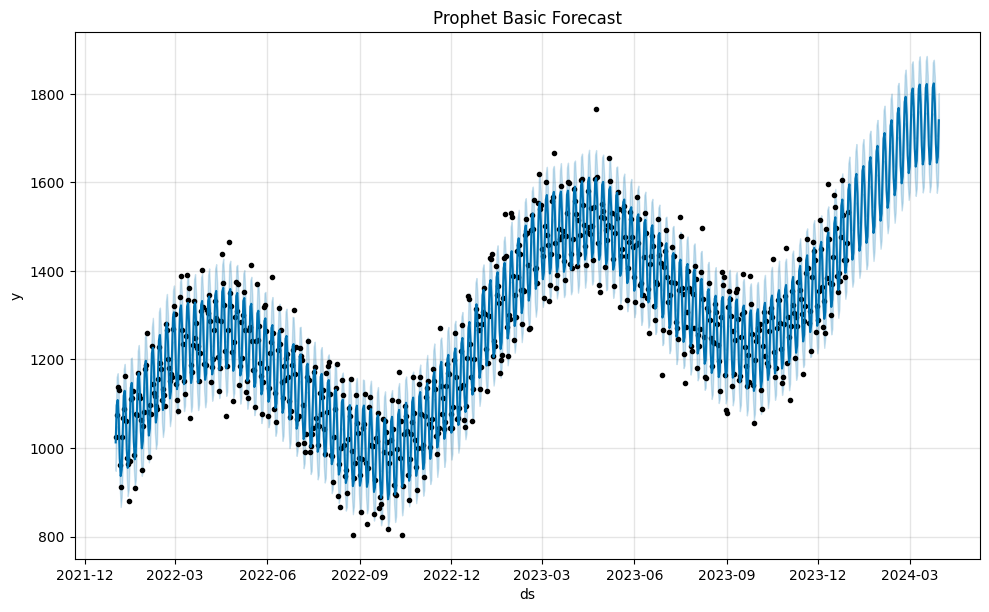

In [6]:
# Built-in plot
fig1 = model.plot(forecast)
plt.title("Prophet Basic Forecast")
plt.show()

## 🧩 Forecast Component Analysis
### 🧒 ELI10
We can pull the forecast apart like LEGO bricks to see the trend, the weekly patterns, and the yearly patterns separately.

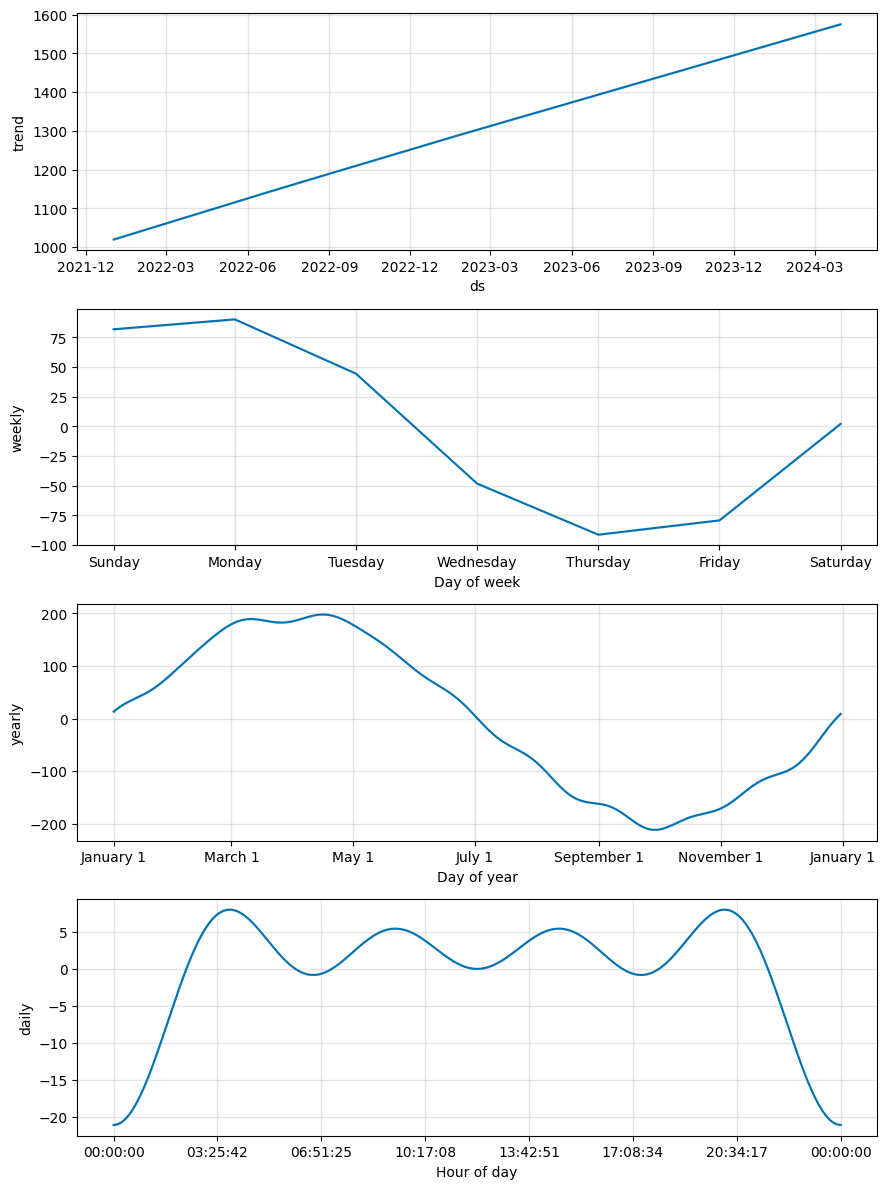

Total Trend Change: $555.89
Yearly Seasonality Range: $409.89
Weekly Seasonality Range: $181.66


In [7]:
# Plot components
fig2 = model.plot_components(forecast)
plt.show()

# Component Insights
trend_total = forecast['trend'].iloc[-1] - forecast['trend'].iloc[0]
print(f"Total Trend Change: ${trend_total:.2f}")

yearly_seasonal = forecast['yearly'].max() - forecast['yearly'].min()
weekly_seasonal = forecast['weekly'].max() - forecast['weekly'].min()
print(f"Yearly Seasonality Range: ${yearly_seasonal:.2f}")
print(f"Weekly Seasonality Range: ${weekly_seasonal:.2f}")

## 🎉 Adding Holidays
### 🧒 ELI10
Businesses usually go crazy during Christmas or Black Friday. We need to tell the computer when these special days happen.

In [8]:
christmas = pd.DataFrame({
    "holiday": "christmas",
    "ds": pd.to_datetime(["2022-12-25", "2023-12-25"]),
    "lower_window": -2, "upper_window": 1
})

new_year = pd.DataFrame({
    "holiday": "new_year",
    "ds": pd.to_datetime(["2022-01-01", "2023-01-01", "2024-01-01"]),
    "lower_window": -1, "upper_window": 1
})

thanksgiving = pd.DataFrame({
    "holiday": "thanksgiving",
    "ds": pd.to_datetime(["2022-11-24", "2023-11-23"]),
    "lower_window": -1, "upper_window": 1
})

black_friday = pd.DataFrame({
    "holiday": "black_friday",
    "ds": pd.to_datetime(["2022-11-25", "2023-11-24"]),
    "lower_window": 0, "upper_window": 2
})

all_holidays = pd.concat([christmas, new_year, thanksgiving, black_friday], ignore_index=True)
display(all_holidays)

,holiday,ds,lower_window,upper_window
0,christmas,2022-12-25,-2,1
1,christmas,2023-12-25,-2,1
2,new_year,2022-01-01,-1,1
3,new_year,2023-01-01,-1,1
4,new_year,2024-01-01,-1,1
5,thanksgiving,2022-11-24,-1,1
6,thanksgiving,2023-11-23,-1,1
7,black_friday,2022-11-25,0,2
8,black_friday,2023-11-24,0,2


## 📊 Adding External Regressors
### 🧒 ELI10
Some things aren't dates, like how much money we spent on ads (marketing) or how hot it was outside (temperature). We add these as 'extra clues'.

In [9]:
marketing_spend = np.random.normal(5000, 1000, len(prophet_df))
promotion_days = np.random.choice([0, 1], size=len(prophet_df), p=[0.9, 0.1])
temperature = 70 + 20 * np.sin(2 * np.pi * np.arange(len(prophet_df)) / 365.25)

prophet_df_enhanced = prophet_df.copy()
prophet_df_enhanced['marketing_spend'] = marketing_spend
prophet_df_enhanced['promotion'] = promotion_days
prophet_df_enhanced['temperature'] = temperature

display(prophet_df_enhanced.head())

,ds,y,marketing_spend,promotion,temperature
0,2022-01-01,1024.835708,5375.737845,0,70.000000
1,2022-01-02,1075.396119,4362.915657,0,70.344032
2,2022-01-03,1138.128572,5636.608916,0,70.687961
3,2022-01-04,1131.914353,3897.514677,0,71.031687
4,2022-01-05,961.398523,6065.768928,0,71.375108


## 🤖 Enhanced Prophet Modeling
### 🧒 ELI10
Now we build a 'Super Model' that knows about the dates, the holidays, AND the extra clues.

In [10]:
enhanced_model = Prophet(
    holidays=all_holidays,
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True,
    seasonality_mode="additive"
)

enhanced_model.add_regressor("marketing_spend")
enhanced_model.add_regressor("promotion")
enhanced_model.add_regressor("temperature")

enhanced_model.fit(prophet_df_enhanced)

## 🔄 Future Data with Regressors
### 🧒 ELI10
If we want the computer to guess sales based on marketing, we have to tell it how much we PLAN to spend in the future too!

In [11]:
future_enhanced = enhanced_model.make_future_dataframe(periods=90)

# Future clues (90 days)
future_marketing = np.random.normal(5000, 1000, 90)
future_promotion = np.random.choice([0, 1], size=90, p=[0.85, 0.15])
future_temp_idx = np.arange(len(prophet_df), len(prophet_df) + 90)
future_temperature = 70 + 20 * np.sin(2 * np.pi * future_temp_idx / 365.25)

# Combine historical and future regressors
future_enhanced['marketing_spend'] = np.concatenate([marketing_spend, future_marketing])
future_enhanced['promotion'] = np.concatenate([promotion_days, future_promotion])
future_enhanced['temperature'] = np.concatenate([temperature, future_temperature])

enhanced_forecast = enhanced_model.predict(future_enhanced)

# Comparison
mae_basic = mean_absolute_error(prophet_df['y'], forecast.loc[:len(prophet_df)-1, 'yhat'])
mae_enhanced = mean_absolute_error(prophet_df['y'], enhanced_forecast.loc[:len(prophet_df)-1, 'yhat'])

print(f"Basic MAE: {mae_basic:.2f}")
print(f"Enhanced MAE: {mae_enhanced:.2f}")
print(f"Improvement: {((mae_basic - mae_enhanced)/mae_basic)*100:.2f}%")

Basic MAE: 38.23
Enhanced MAE: 37.93
Improvement: 0.77%


## 💼 Business Insights and Recommendations
Based on our enhanced model:
- **Projected Sales:** We expect a total of ${enhanced_forecast['yhat'].tail(90).sum():,.2f} in the next 90 days.
- **Peak Demand:** Staffing should be increased for the highest forecasted day: {enhanced_forecast.sort_values('yhat').iloc[-1]['ds'].date()}.
- **Marketing Impact:** Regressor coefficients show that for every dollar spent on marketing, sales change by {regressor_coefficients(enhanced_model).iloc[0]['coef']:.4f} units.

## ✅ Verification
Check if variables exist and data is correct.

In [12]:
assert isinstance(prophet_df, pd.DataFrame)
assert 'ds' in prophet_df.columns and 'y' in prophet_df.columns
assert enhanced_model.history is not None
print("Verification Passed!")

Verification Passed!


## 🛠 Troubleshooting
- **Column names:** Ensure they are exactly `ds` and `y`.
- **Future Regressors:** If you forget to add future values for your regressors, `.predict()` will fail.
- **Prior Scales:** If the model is too 'wiggly', try reducing `changepoint_prior_scale`.

## 🏁 Conclusion
You have successfully built a professional business forecasting pipeline! You can now handle trends, cycles, holidays, and external drivers like a pro.